In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

os.chdir("../")
print("Current work path:", os.getcwd())

Current work path: /home/pengxy2024/ICLR2026


In [3]:
eta_path = "experiments/data/eta_sensitive/exp_on_k=20.json"
eta_data = json.load(open(eta_path, "r"))

etas = [1, 20, 100]
B = [2000, 20000]
online_avg_rewards_2000b = {eta: sum(eta_data[f"rb_on_AUPD_{eta}"][0]) / 5 for eta in etas}
offline_avg_rewards_2000b = {eta: sum(eta_data[f"rb_off_AUPD_{eta}"][0]) / 5 for eta in etas}
online_avg_rewards_20000b = {eta: sum(eta_data[f"rb_on_AUPD_{eta}"][1]) / 5 for eta in etas}
offline_avg_rewards_20000b = {eta: sum(eta_data[f"rb_off_AUPD_{eta}"][1]) / 5 for eta in etas}

oline_std_rewards_2000b = {eta: np.std(eta_data[f"rb_on_AUPD_{eta}"][0]) for eta in etas}
offline_std_rewards_2000b = {eta: np.std(eta_data[f"rb_off_AUPD_{eta}"][0]) for eta in etas}
oline_std_rewards_20000b = {eta: np.std(eta_data[f"rb_on_AUPD_{eta}"][1]) for eta in etas}
offline_std_rewards_20000b = {eta: np.std(eta_data[f"rb_off_AUPD_{eta}"][1]) for eta in etas}



In [4]:
def general_beautify(ax):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_facecolor('white')
    ax.margins(0.02)


colorset = [[84 / 255, 111 / 255, 198 / 255],  
            [145 / 255, 203 / 255, 116 / 255], 
            [250 / 255, 200 / 255, 89 / 255], 
            [238 / 255, 102 / 255, 102 / 255],
            [115 / 255, 192 / 255, 222 / 255],
            [59 / 255, 163 / 255, 114 / 255], 
            [252 / 255, 132 / 255, 82 / 255], 
            [154 / 255, 96 / 255, 180 / 255], 
            # [142 / 255, 51 / 255, 138 / 255],
            ]

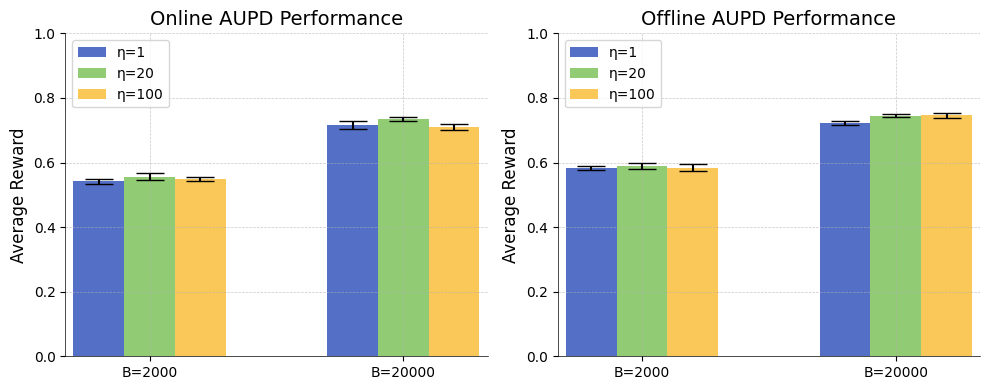

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax in axs:
    general_beautify(ax)

x = np.arange(0, 1, step=0.5)
width = 0.1
# Online AUPD
for i, eta in enumerate(etas):
    axs[0].bar(x[0] + i * width, online_avg_rewards_2000b[eta], width, yerr=oline_std_rewards_2000b[eta], label=f'η={eta}', color=colorset[i], capsize=10)
    axs[0].bar(x[1] + i * width, online_avg_rewards_20000b[eta], width, yerr=oline_std_rewards_20000b[eta], color=colorset[i], capsize=10)
axs[0].set_ylabel('Average Reward', fontsize=12)
# axs[0].set_title('Online AUPD Performance', fontsize=14)
axs[0].set_xticks(x + width)
axs[0].set_xticklabels(["B=2000", "B=20000"])
axs[0].legend(fontsize=10, loc='upper left')
axs[0].set_ylim(0, 1)

# Offline AUPD
for i, eta in enumerate(etas):
    axs[1].bar(x[0] + i * width, offline_avg_rewards_2000b[eta], width, yerr=offline_std_rewards_2000b[eta], label=f'η={eta}', color=colorset[i], capsize=10)
    axs[1].bar(x[1] + i * width, offline_avg_rewards_20000b[eta], width, yerr=offline_std_rewards_20000b[eta], color=colorset[i], capsize=10)
axs[1].set_ylabel('Average Reward', fontsize=12)
# axs[1].set_title('Offline AUPD Performance', fontsize=14)
axs[1].set_xticks(x + width)
axs[1].set_xticklabels(["B=2000", "B=20000"])
axs[1].legend(fontsize=10, loc='upper left')
axs[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('img/eta_sensitive.pdf', format='pdf', bbox_inches='tight')
plt.show()